# CardioIA — análise do baseline tabular

Este notebook reproduz o treinamento, avalia o modelo no conjunto de teste e apresenta incerteza, desempenho por sexo e faixa etária, calibração e interpretação das variáveis. A análise utiliza somente a modalidade numérica Cleveland e tem finalidade acadêmica.

## Preparação e execução

O pré-processamento é ajustado apenas no treino dentro de um `Pipeline`. A divisão é estratificada, com 80% para treino e 20% para teste e semente 42.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

RAIZ = Path.cwd()
if not (RAIZ / 'fase2').exists():
    if RAIZ.name == 'notebooks' and RAIZ.parent.name == 'fase2':
        RAIZ = RAIZ.parents[1]
    else:
        raise RuntimeError('Abra o notebook a partir da raiz do repositório ou da pasta fase2/notebooks.')
os.chdir(RAIZ)

subprocess.run([sys.executable, 'fase2/src/treinar_baselines.py'], check=True)
subprocess.run([sys.executable, 'fase2/src/analisar_modelo.py'], check=True)

Out[0]: CompletedProcess(args=['/tmp/cardioia-ponto4-venv/bin/python', 'fase2/src/analisar_modelo.py'], returncode=0)


## Comparação dos modelos

In [2]:
import pandas as pd
from IPython.display import display

cv = pd.read_csv('fase2/resultados/metricas_validacao_cruzada.csv')
display(cv.pivot(index='modelo', columns='metrica', values='media').round(3))

teste = pd.read_csv('fase2/resultados/metricas_teste.csv')
display(teste.round(3))

metrica,acuracia,f1,precisao,recall_sensibilidade,roc_auc
modelo,,,,,
random_forest,0.801,0.784,0.786,0.792,0.900
regressao_logistica,0.847,0.831,0.848,0.819,0.907


,modelo,n,n_positivos,prevalencia_observada,acuracia,precisao,recall_sensibilidade,f1,taxa_falso_positivo,taxa_falso_negativo,roc_auc
0,regressao_logistica,61,28,0.459,0.869,0.812,0.929,0.867,0.182,0.071,0.958


## Incerteza e desempenho por sexo e faixa etária

Os intervalos de confiança de 95% são estimados por 2.000 reamostragens bootstrap. As faixas foram definidas antes da leitura das métricas: até 49 anos, 50 a 59 anos e 60 anos ou mais. Todos os subgrupos são pequenos e os resultados são apenas descritivos.

In [3]:
por_sexo = pd.read_csv('fase2/resultados/metricas_por_sexo.csv')
por_idade = pd.read_csv('fase2/resultados/metricas_por_faixa_etaria.csv')
intervalos = pd.read_csv('fase2/resultados/intervalos_confianca_bootstrap.csv')
display(por_sexo.round(3))
display(por_idade.round(3))
display(intervalos.round(3))

,modelo,sexo,n,n_positivos,prevalencia_observada,acuracia,precisao,recall_sensibilidade,f1,taxa_falso_positivo,taxa_falso_negativo,roc_auc
0,regressao_logistica,feminino,20,7,0.350,0.950,1.000,0.857,0.923,0.0,0.143,1.000
1,regressao_logistica,masculino,41,21,0.512,0.829,0.769,0.952,0.851,0.3,0.048,0.938


,modelo,faixa_etaria,n,n_positivos,prevalencia_observada,acuracia,precisao,recall_sensibilidade,f1,taxa_falso_positivo,taxa_falso_negativo,roc_auc
0,regressao_logistica,até 49 anos,18,5,0.278,1.000,1.000,1.000,1.000,0.000,0.000,1.000
1,regressao_logistica,50 a 59 anos,25,12,0.480,0.840,0.786,0.917,0.846,0.231,0.083,0.981
2,regressao_logistica,60 anos ou mais,18,11,0.611,0.778,0.769,0.909,0.833,0.429,0.091,0.870


,dimensao,grupo,n,metrica,estimativa,ic95_inferior,ic95_superior,reamostragens_validas
0,geral,geral,61,acuracia,0.869,0.770,0.951,2000
1,geral,geral,61,precisao,0.812,0.667,0.938,2000
2,geral,geral,61,recall_sensibilidade,0.929,0.815,1.000,2000
3,geral,geral,61,f1,0.867,0.762,0.947,2000
4,geral,geral,61,taxa_falso_positivo,0.182,0.061,0.333,2000
5,geral,geral,61,taxa_falso_negativo,0.071,0.000,0.185,2000
6,geral,geral,61,roc_auc,0.958,0.898,0.996,2000
7,sexo,feminino,20,acuracia,0.950,0.850,1.000,2000
8,sexo,feminino,20,precisao,1.000,1.000,1.000,2000
9,sexo,feminino,20,recall_sensibilidade,0.857,0.556,1.000,2000


## Visualizações de desempenho

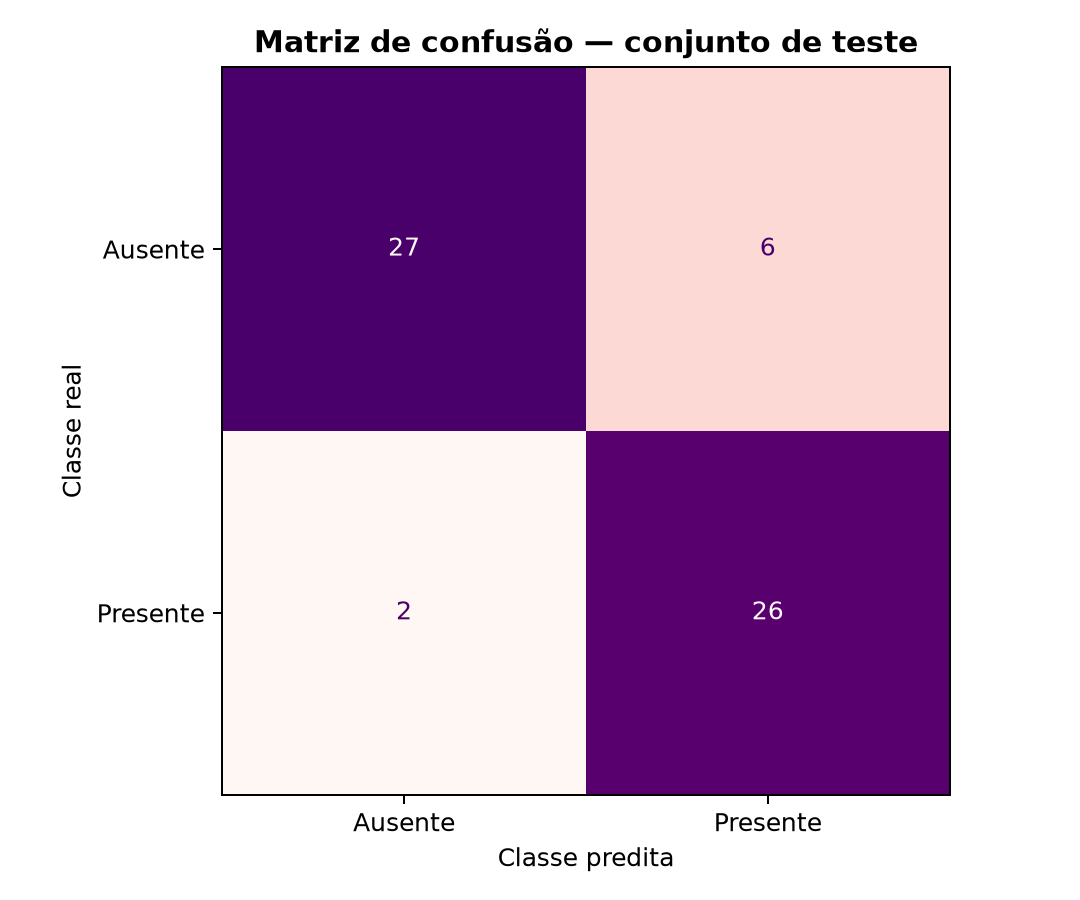

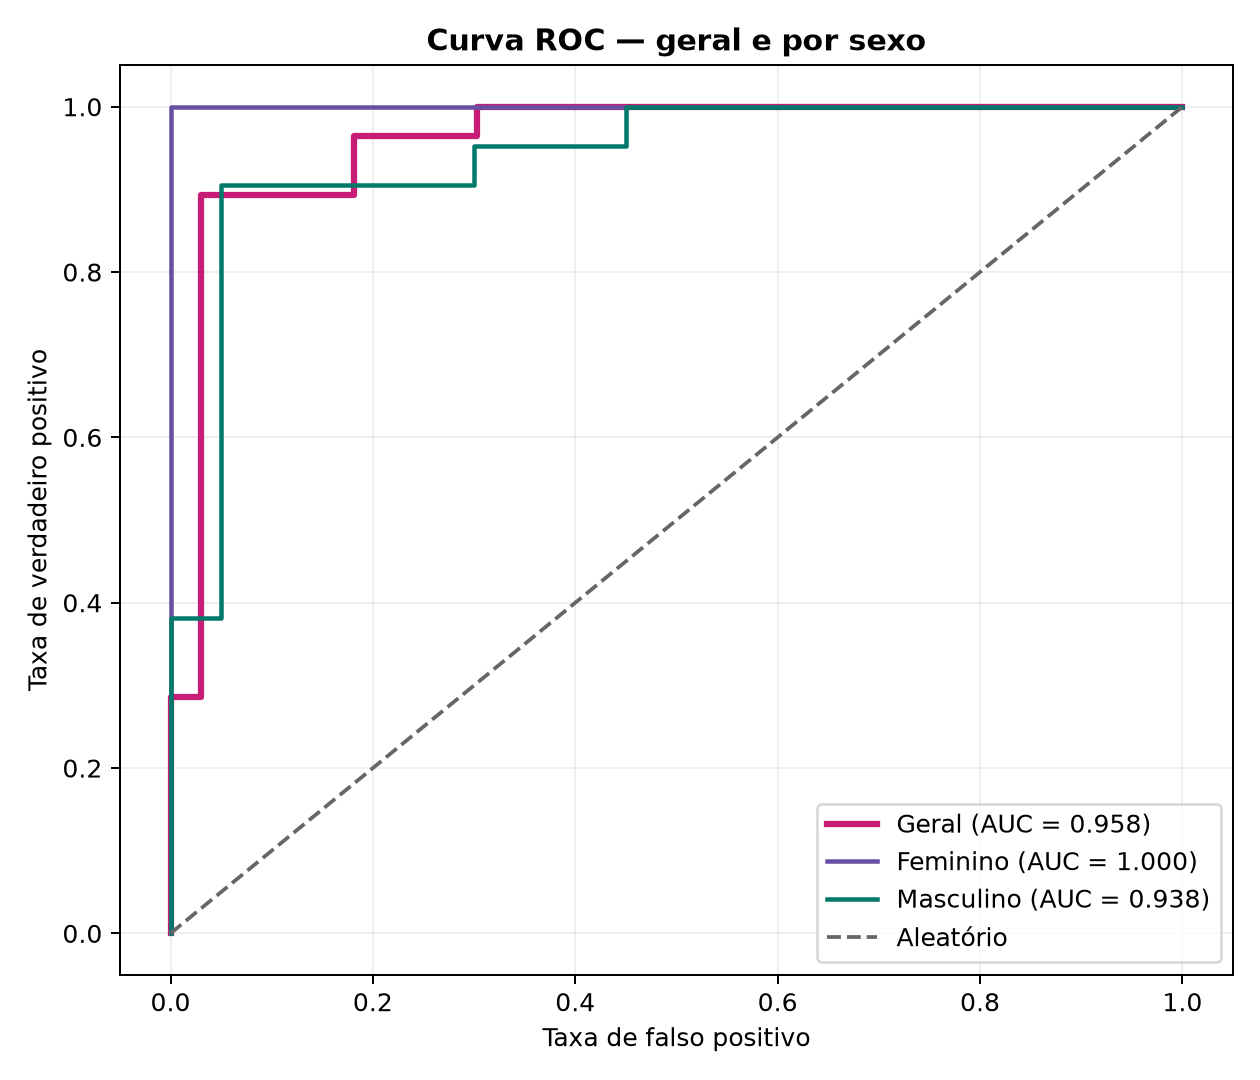

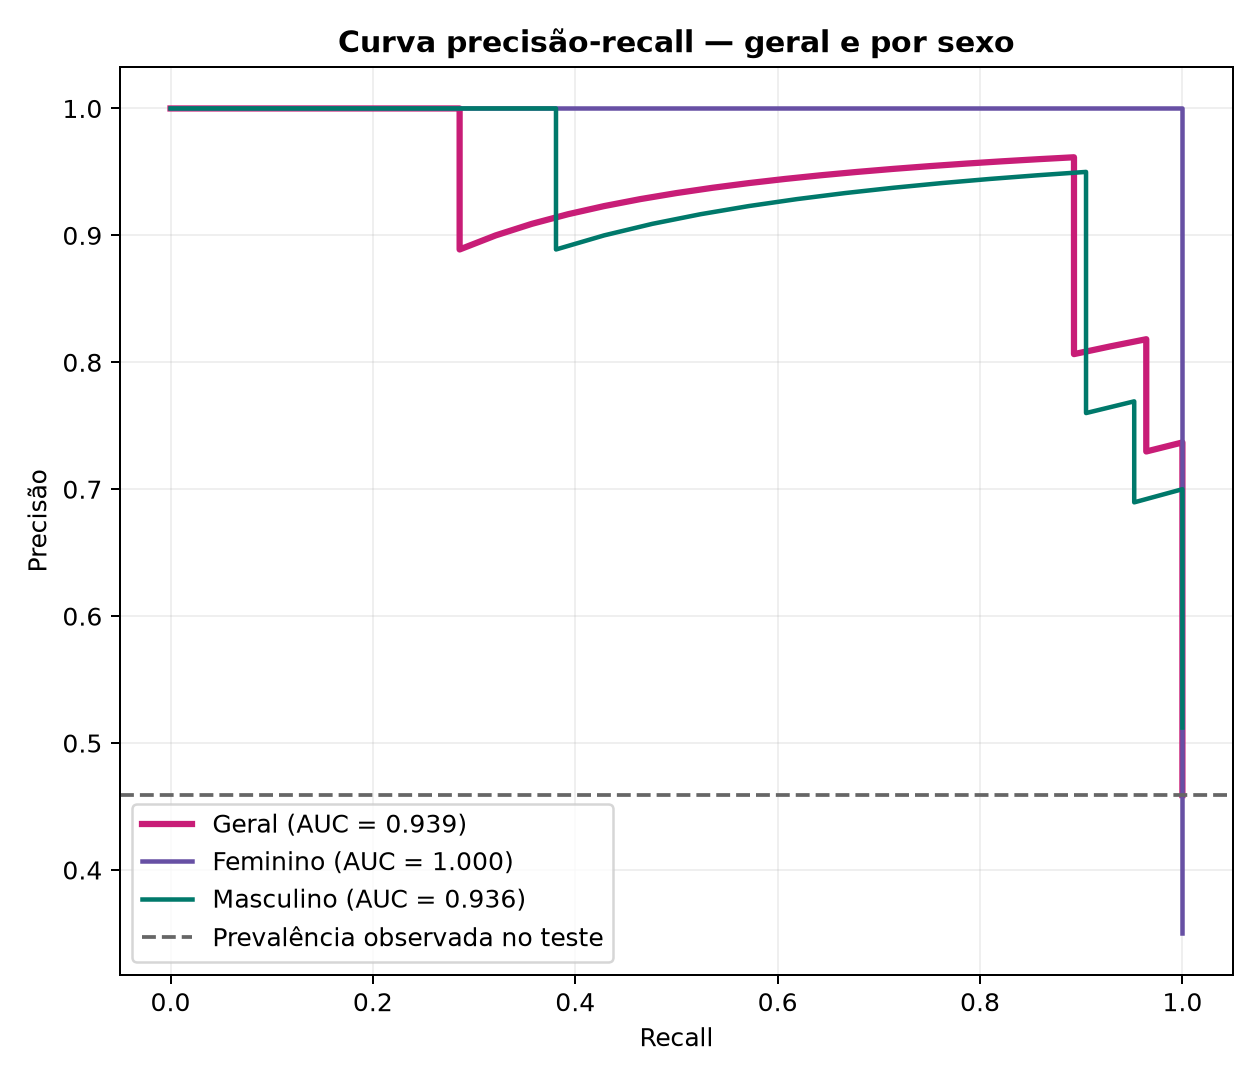

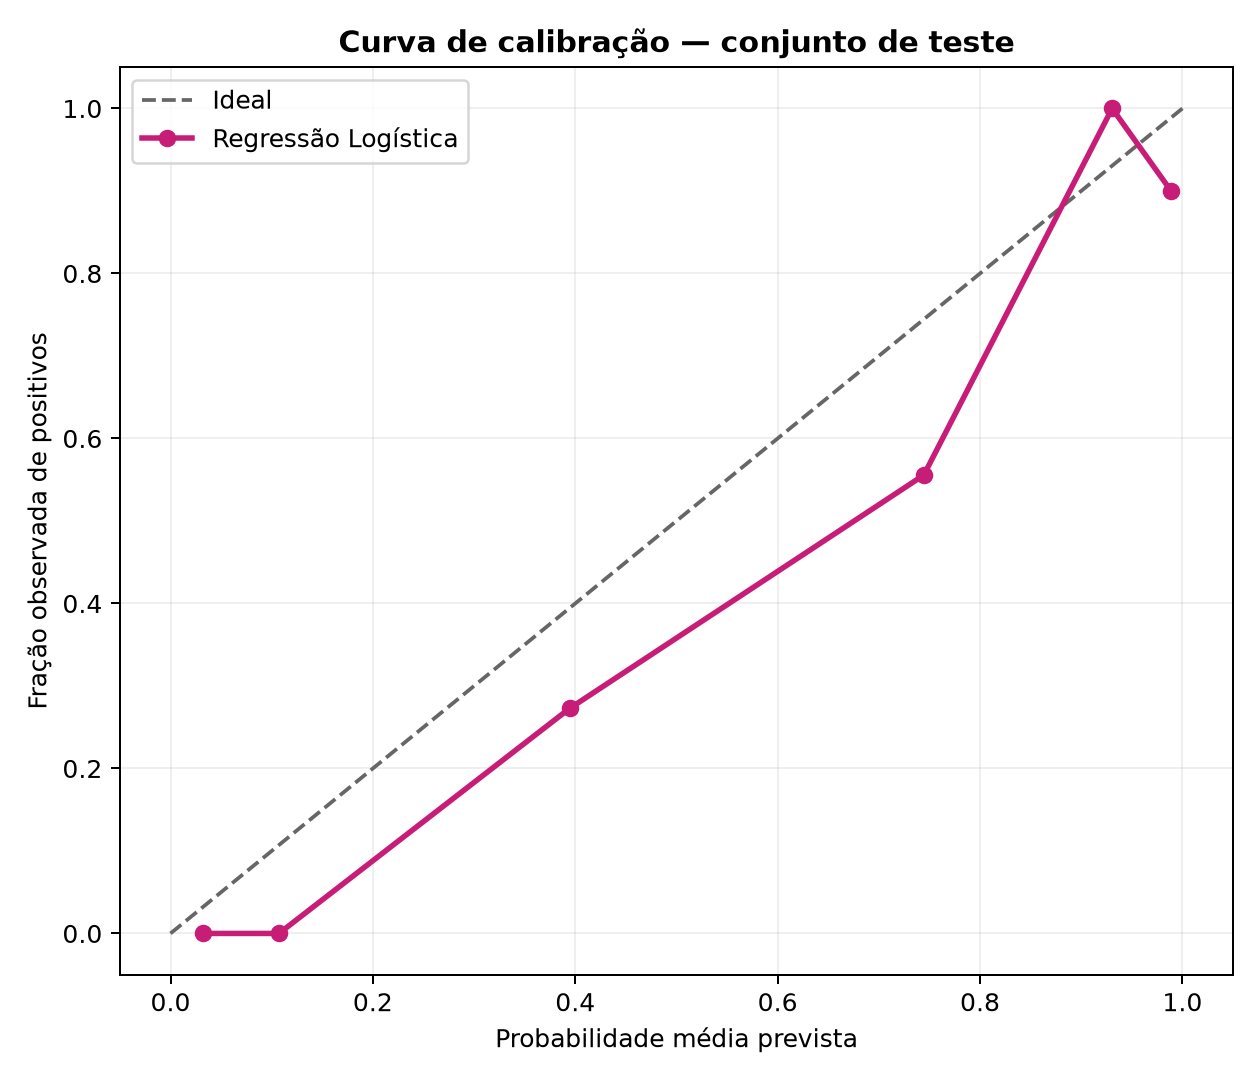

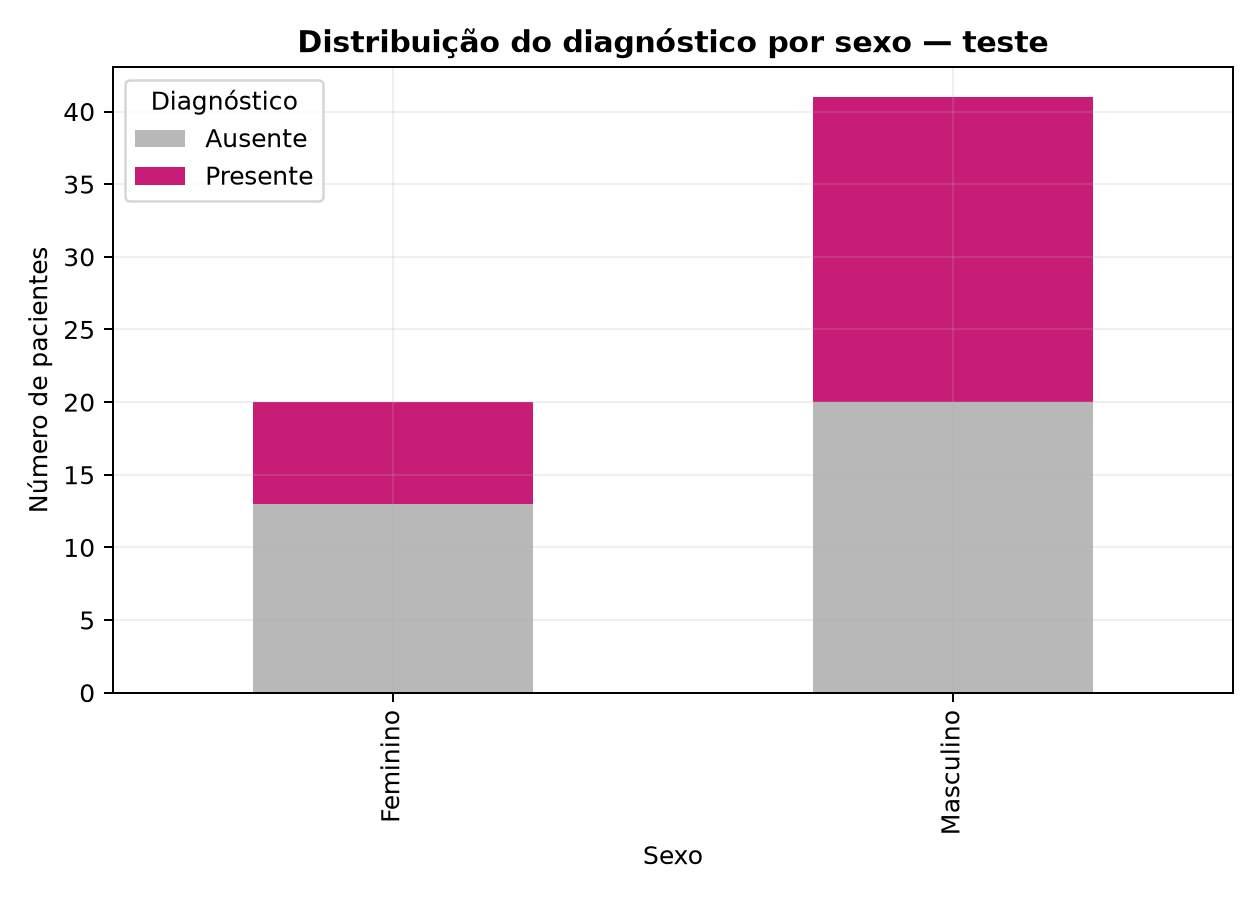

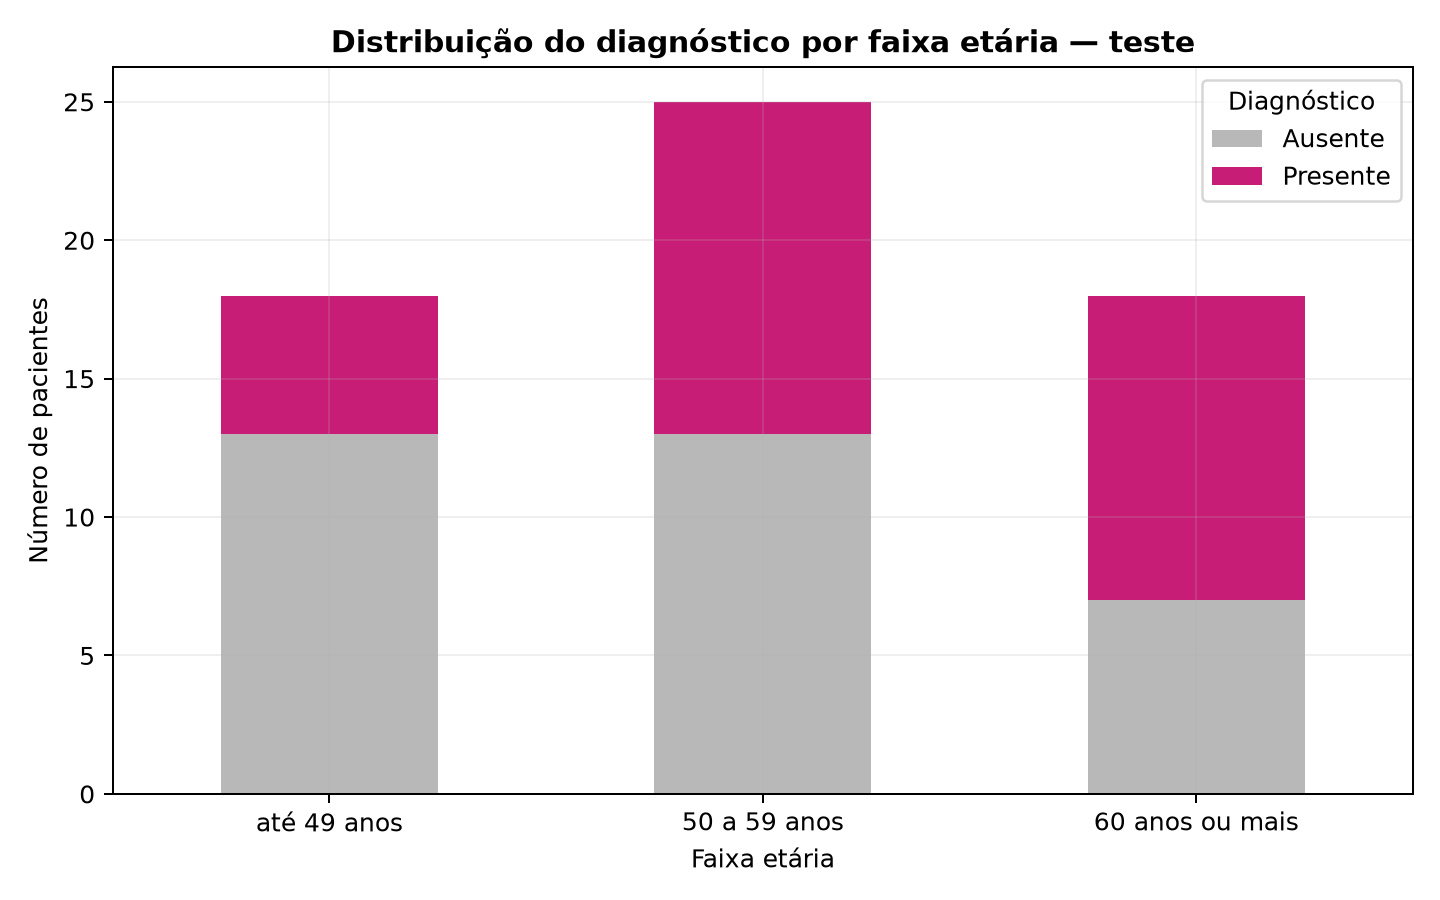

In [4]:
from IPython.display import Image, display

graficos = [
    'matriz_confusao.png',
    'curva_roc.png',
    'curva_precisao_recall.png',
    'curva_calibracao.png',
    'distribuicao_alvo_por_sexo.png',
    'distribuicao_alvo_por_faixa_etaria.png',
]
for grafico in graficos:
    display(Image(filename=f'fase2/resultados/graficos/{grafico}', width=720))

## Interpretação das variáveis

Coeficientes positivos aumentam o logaritmo da chance predita da classe `presente`; coeficientes negativos reduzem essa chance. Eles representam associação no modelo, não causalidade clínica.

,variavel_transformada,coeficiente,magnitude_absoluta
0,num_vasos_principais,1.1336,1.1336
1,tipo_dor_peito_assintomatico,0.9773,0.9773
2,resultado_thal_defeito_reversivel,0.8006,0.8006
3,sexo_feminino,-0.7362,0.7362
4,sexo_masculino,0.7335,0.7335
5,tipo_dor_peito_angina_tipica,-0.6307,0.6307
6,inclinacao_st_pico_exercicio_plana,0.6080,0.6080
7,resultado_thal_normal,-0.5536,0.5536
8,inclinacao_st_pico_exercicio_ascendente,-0.4935,0.4935
9,tipo_dor_peito_dor_nao_anginosa,-0.4926,0.4926


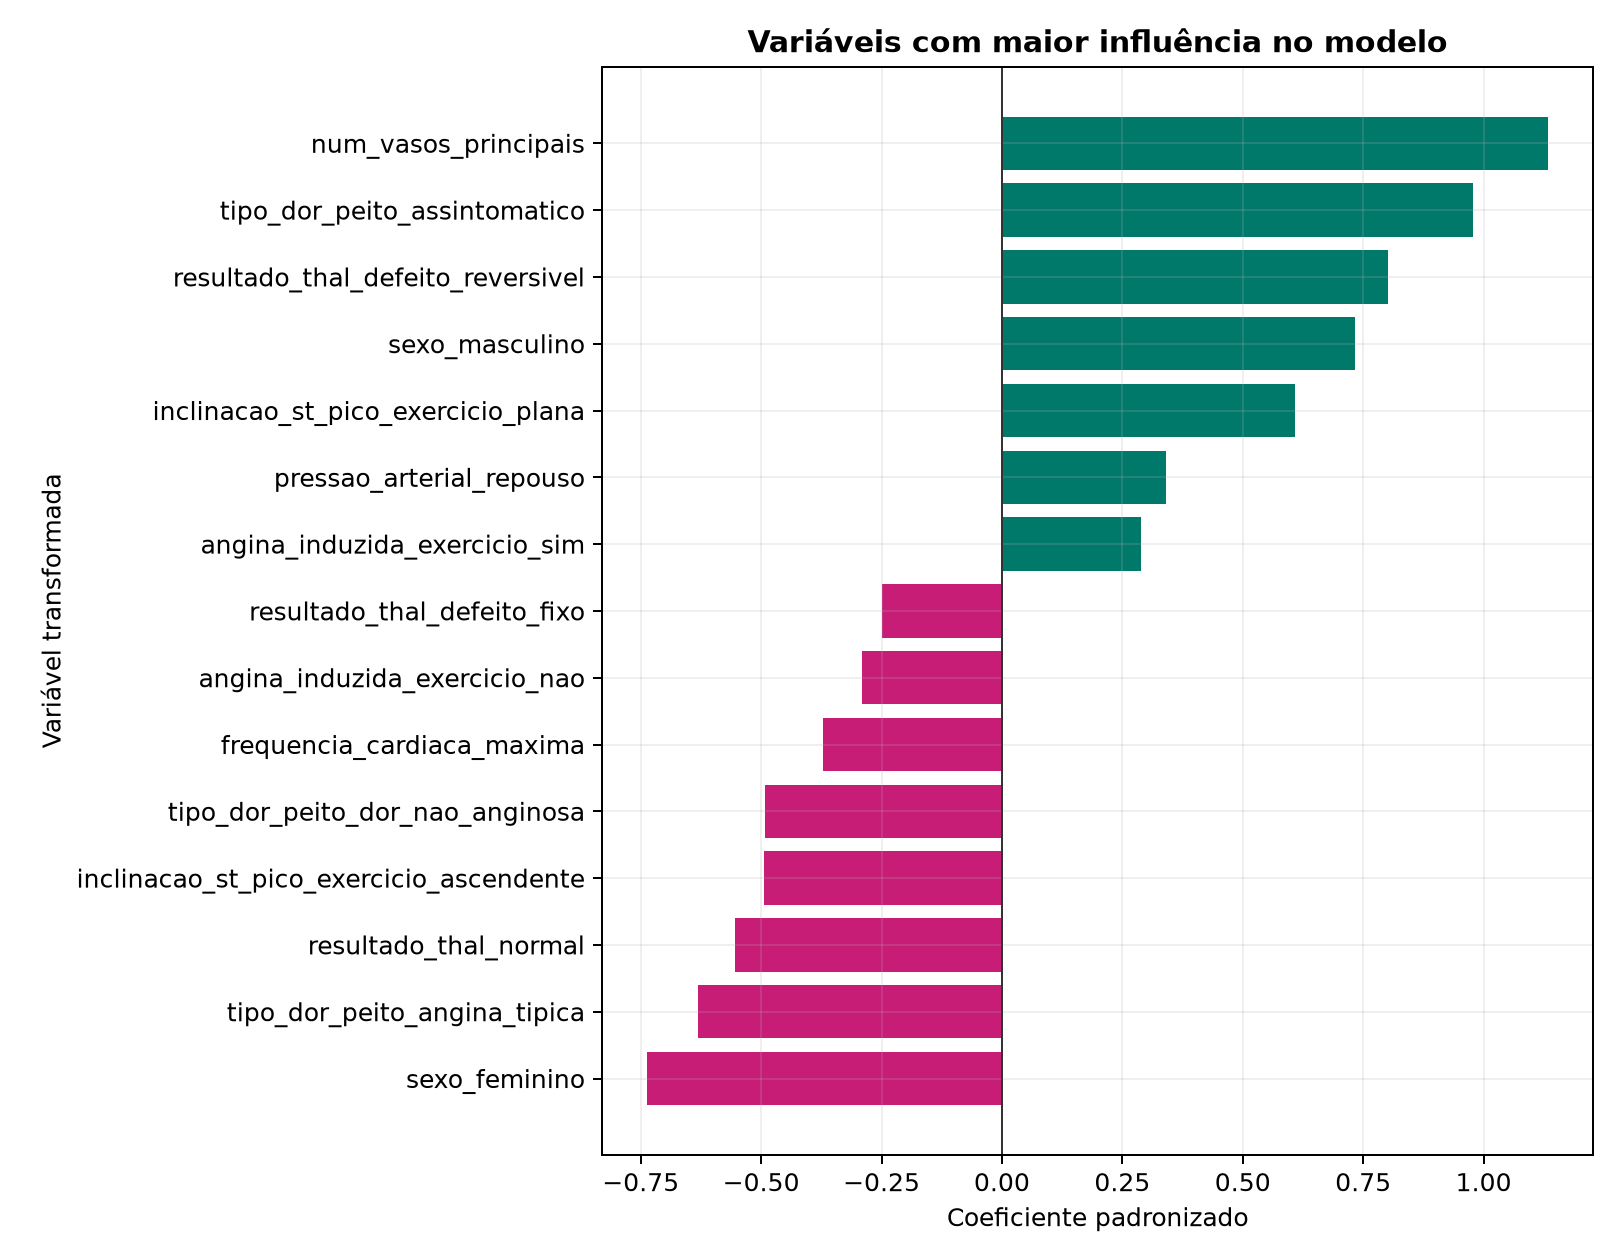

In [5]:
importancias = pd.read_csv('fase2/resultados/importancia_variaveis.csv')
display(importancias.head(20).round(4))
display(Image(filename='fase2/resultados/graficos/importancia_variaveis.png', width=850))

## Limitações

- A base contém somente 303 pacientes de uma instituição dos Estados Unidos, coletados na década de 1980.
- O conjunto de teste possui apenas 61 pacientes; métricas gerais, por sexo e por faixa etária têm incerteza relevante.
- As avaliações demográficas são descritivas e não demonstram, sozinhas, presença ou ausência de viés.
- O desempenho não pode ser generalizado para a população brasileira nem utilizado em decisões clínicas.
- Dados numéricos, textuais e visuais permanecem como modalidades independentes.